**Model 1**

In [3]:
!wget https://www.openslr.org/resources/103/Hindi_test.tar.gz

--2026-09-15 17:21:52--  https://www.openslr.org/resources/103/Hindi_test.tar.gz
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 258984925 (247M) [application/x-gzip]
Saving to: ‘Hindi_test.tar.gz’

Hindi_test.tar.gz   100%[===================>] 246.99M  13.1MB/s    in 20s     

2026-09-15 17:22:13 (12.4 MB/s) - ‘Hindi_test.tar.gz’ saved [258984925/258984925]



In [4]:
!tar -xzf Hindi_test.tar.gz

In [5]:
from IPython.display import Audio, display

for i, file in enumerate(test_files, 1):
    print(f"Input {i}: {file}")
    display(Audio(file))

In [13]:
!find . -maxdepth 3 -type f | head -30

./.config/.last_opt_in_prompt.yaml
./.config/configurations/config_default
./.config/config_sentinel
./.config/default_configs.db
./.config/active_config
./.config/gce
./.config/.last_survey_prompt.yaml
./.config/.last_update_check.json
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./Hindi_test.tar.gz
./test/audio/3864_098.wav
./test/audio/5921_061.wav
./test/audio/1477_086.wav
./test/audio/2070_008.wav
./test/audio/0308_061.wav
./test/audio/5537_061.wav
./test/audio/0818_086.wav
./test/audio/1113_003.wav
./test/audio/4792_086.wav
./test/audio/5973_061.wav
./test/audio/1362_087.wav
./test/audio/2452_008.wav
./test/audio/1161_028.wav
./test/audio/4533_088.wav
./test/audio/5789_066.wav
./test/audio/2010_086.wav
./test/audio/1731_003.wav
./test/audio/1098_098.wav
./test/audio/1019_008.wav
./test/audio/1317_028.wav


In [6]:
!pip install -q -U transformers librosa soundfile sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 27.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [7]:
import transformers
import librosa
import soundfile as sf
import torch

print("Transformers:", transformers.__version__)
print("Librosa:", librosa.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Transformers: 5.17.0
Librosa: 1.0.0
PyTorch: 2.11.0+cu128
CUDA: True


In [8]:
from transformers import AutoProcessor, SeamlessM4Tv2Model

model_name = "facebook/seamless-m4t-v2-large"

processor = AutoProcessor.from_pretrained(model_name)

model = SeamlessM4Tv2Model.from_pretrained(
    model_name,
    torch_dtype=torch.float16
).to("cuda")

print("Model loaded!")

preprocessor_config.json:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.72k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.7k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B / 5.17MB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] Instantiating a decoder SeamlessM4Tv2Attention without passing `layer_idx` is not recommended and will lead to errors during the forward call, if caching is used. Please make sure to provide a `layer_idx` when creating this class.


Loading weights:   0%|          | 0/2232 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/9.91M [00:00<?, ?B/s]

Model loaded!


In [9]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [10]:
import glob
import os
import librosa
import soundfile as sf
import torch

audio_files = glob.glob("/content/test/audio/*.wav")
test_files = audio_files[:10]

os.makedirs("/content/output", exist_ok=True)

for i, input_file in enumerate(test_files, 1):

    print(f"Processing {i}/10: {input_file}")

    # Load Hindi audio
    audio, sr = librosa.load(
        input_file,
        sr=16000,
        mono=True
    )

    # Prepare input
    inputs = processor(
        audio=audio,
        sampling_rate=16000,
        src_lang="hin",
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    # Hindi → Bengali
    with torch.no_grad():
        output = model.generate(
            **inputs,
            tgt_lang="ben",
            generate_speech=True
        )

    # Get generated Bengali waveform
    bengali_audio = (
        output[0][0]
        .cpu()
        .float()
        .numpy()
        .squeeze()
    )

    # Save audio
    output_file = f"/content/output/hindi_to_bengali_{i}.wav"

    sf.write(
        output_file,
        bengali_audio,
        16000
    )

    print(f"Saved: {output_file}")

print("\nDONE!")

Processing 1/10: /content/test/audio/3864_098.wav
Saved: /content/output/hindi_to_bengali_1.wav
Processing 2/10: /content/test/audio/5921_061.wav
Saved: /content/output/hindi_to_bengali_2.wav
Processing 3/10: /content/test/audio/1477_086.wav
Saved: /content/output/hindi_to_bengali_3.wav
Processing 4/10: /content/test/audio/2070_008.wav
Saved: /content/output/hindi_to_bengali_4.wav
Processing 5/10: /content/test/audio/0308_061.wav
Saved: /content/output/hindi_to_bengali_5.wav
Processing 6/10: /content/test/audio/5537_061.wav
Saved: /content/output/hindi_to_bengali_6.wav
Processing 7/10: /content/test/audio/0818_086.wav
Saved: /content/output/hindi_to_bengali_7.wav
Processing 8/10: /content/test/audio/1113_003.wav
Saved: /content/output/hindi_to_bengali_8.wav
Processing 9/10: /content/test/audio/4792_086.wav
Saved: /content/output/hindi_to_bengali_9.wav
Processing 10/10: /content/test/audio/5973_061.wav
Saved: /content/output/hindi_to_bengali_10.wav

DONE!


In [11]:
import glob

files = glob.glob("/content/output/*.wav")

print("Generated files:", len(files))
print(files)

Generated files: 10
['/content/output/hindi_to_bengali_5.wav', '/content/output/hindi_to_bengali_4.wav', '/content/output/hindi_to_bengali_7.wav', '/content/output/hindi_to_bengali_10.wav', '/content/output/hindi_to_bengali_1.wav', '/content/output/hindi_to_bengali_9.wav', '/content/output/hindi_to_bengali_3.wav', '/content/output/hindi_to_bengali_8.wav', '/content/output/hindi_to_bengali_6.wav', '/content/output/hindi_to_bengali_2.wav']


In [12]:
from IPython.display import Audio, display

for i in range(1, 11):
    print(f"Output {i}:")
    display(Audio(f"/content/output/hindi_to_bengali_{i}.wav"))

Output 1:


Output 2:


Output 3:


Output 4:


Output 5:


Output 6:


Output 7:


Output 8:


Output 9:


Output 10:


In [13]:
!pip install -q jiwer nltk sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 12.9 MB/s eta 0:00:00


In [14]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
import librosa
import numpy as np
import pandas as pd
import glob
import os

output_files = sorted(
    glob.glob("/content/output/hindi_to_bengali_*.wav")
)

print("Files found:", len(output_files))

Files found: 10


Metric Evaluation

In [19]:
results = []

for file in output_files:

    # Load generated Bengali audio
    y, sr = librosa.load(file, sr=None, mono=True)

    # 1. RMS Energy
    rms = np.sqrt(np.mean(y ** 2))

    # 2. Zero Crossing Rate
    zcr = np.mean(
        librosa.feature.zero_crossing_rate(y)[0]
    )

    # 3. Spectral Centroid
    spectral_centroid = np.mean(
        librosa.feature.spectral_centroid(
            y=y,
            sr=sr
        )[0]
    )

    # 4. SNR estimation
    # Estimate noise using the quieter portions of the signal
    signal_power = np.mean(y ** 2)

    threshold = np.percentile(np.abs(y), 20)
    noise = y[np.abs(y) <= threshold]

    if len(noise) > 0:
        noise_power = np.mean(noise ** 2)
        snr = 10 * np.log10(
            signal_power / (noise_power + 1e-10)
        )
    else:
        snr = np.nan

    results.append({
        "File": os.path.basename(file),
        "SNR (dB)": snr,
        "RMS Energy": rms,
        "ZCR": zcr,
        "Spectral Centroid (Hz)": spectral_centroid
    })

df = pd.DataFrame(results)

df

,File,SNR (dB),RMS Energy,ZCR,Spectral Centroid (Hz)
0,hindi_to_bengali_1.wav,49.312469,0.102843,0.112236,1620.437031
1,hindi_to_bengali_10.wav,56.059155,0.103414,0.097527,1557.579678
2,hindi_to_bengali_2.wav,50.223843,0.122435,0.089631,1460.896796
3,hindi_to_bengali_3.wav,46.210323,0.104067,0.080553,1367.083000
4,hindi_to_bengali_4.wav,41.917629,0.109454,0.124557,1624.649597
5,hindi_to_bengali_5.wav,35.509193,0.106558,0.130651,1654.500230
6,hindi_to_bengali_6.wav,47.091656,0.098835,0.085379,1473.198647
7,hindi_to_bengali_7.wav,44.274715,0.110243,0.100679,1501.061409
8,hindi_to_bengali_8.wav,39.551407,0.114760,0.138467,1673.759791
9,hindi_to_bengali_9.wav,46.183083,0.105465,0.091966,1358.914199


In [20]:
print("Average Metrics:")
print("SNR:", df["SNR (dB)"].mean(), "dB")
print("RMS Energy:", df["RMS Energy"].mean())
print("ZCR:", df["ZCR"].mean())
print("Spectral Centroid:", df["Spectral Centroid (Hz)"].mean(), "Hz")

Average Metrics:
SNR: 45.633347 dB
RMS Energy: 0.10780744
ZCR: 0.10516449556666427
Spectral Centroid: 1529.208037717331 Hz


In [21]:
# Automatically identify possible audio-quality failures

mean_snr = df["SNR (dB)"].mean()
mean_rms = df["RMS Energy"].mean()
mean_zcr = df["ZCR"].mean()
mean_centroid = df["Spectral Centroid (Hz)"].mean()

failures = []

for _, row in df.iterrows():

    sample_failures = []

    # Low SNR → possible noise problem
    if row["SNR (dB)"] < mean_snr - 5:
        sample_failures.append("Low SNR / possible noise")

    # Very different energy → possible volume problem
    if abs(row["RMS Energy"] - mean_rms) > 0.02:
        sample_failures.append("Unusual signal energy")

    # High ZCR → possible noisy/unstable speech signal
    if row["ZCR"] > mean_zcr + 0.03:
        sample_failures.append("High signal variation")

    # Unusual spectral centroid
    if abs(row["Spectral Centroid (Hz)"] - mean_centroid) > 200:
        sample_failures.append("Unusual frequency characteristics")

    if not sample_failures:
        sample_failures.append("No significant signal-level failure")

    failures.append({
        "File": row["File"],
        "Detected Failure": "; ".join(sample_failures)
    })

failure_df = pd.DataFrame(failures)

failure_df

,File,Detected Failure
0,hindi_to_bengali_1.wav,No significant signal-level failure
1,hindi_to_bengali_10.wav,No significant signal-level failure
2,hindi_to_bengali_2.wav,No significant signal-level failure
3,hindi_to_bengali_3.wav,No significant signal-level failure
4,hindi_to_bengali_4.wav,No significant signal-level failure
5,hindi_to_bengali_5.wav,Low SNR / possible noise
6,hindi_to_bengali_6.wav,No significant signal-level failure
7,hindi_to_bengali_7.wav,No significant signal-level failure
8,hindi_to_bengali_8.wav,Low SNR / possible noise; High signal variation
9,hindi_to_bengali_9.wav,No significant signal-level failure


**BlEU+METEUR**

Model 2

In [22]:
!wget -q https://www.openslr.org/resources/103/Marathi_test.tar.gz
!tar -xzf Marathi_test.tar.gz

In [24]:
import glob

files = glob.glob("/content/test/audio/*.wav")

print("Total Marathi audio files:", len(files))
print("First 10 files:")
for f in files[:10]:
    print(f)

Total Marathi audio files: 8518
First 10 files:
/content/test/audio/03_0469_06_2.wav
/content/test/audio/02_1362_10_1.wav
/content/test/audio/01_0785_07_1.wav
/content/test/audio/3864_098.wav
/content/test/audio/01_2989_03_1.wav
/content/test/audio/01_0404_08_1.wav
/content/test/audio/03_0067_01_1.wav
/content/test/audio/5921_061.wav
/content/test/audio/03_0407_05_1.wav
/content/test/audio/03_1074_12_1.wav


In [31]:
from IPython.display import Audio, display

for i, f in enumerate(marathi_files, 1):
    print(f"Input Marathi Audio - Sample {i}")
    display(Audio(f))

Input Marathi Audio - Sample 1


Input Marathi Audio - Sample 2


Input Marathi Audio - Sample 3


Input Marathi Audio - Sample 4


Input Marathi Audio - Sample 5


Input Marathi Audio - Sample 6


Input Marathi Audio - Sample 7


Input Marathi Audio - Sample 8


Input Marathi Audio - Sample 9


Input Marathi Audio - Sample 10


In [25]:
import glob
import os

marathi_files = sorted(glob.glob("/content/test/audio/*.wav"))[:10]

print("Selected 10 Marathi samples:")
for i, f in enumerate(marathi_files, 1):
    print(i, os.path.basename(f))

Selected 10 Marathi samples:
1 0116_003.wav
2 0116_008.wav
3 0116_025.wav
4 0116_036.wav
5 0116_061.wav
6 0116_069.wav
7 0116_086.wav
8 0116_087.wav
9 0116_088.wav
10 0116_089.wav


In [37]:
!pip install -q -U transformers librosa soundfile sentencepiece accelerate
!pip install -q gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.


In [38]:
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "theharshithh/open-sarika-v1"

processor2 = WhisperProcessor.from_pretrained(model_id)

model2 = WhisperForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

print("Model 2 loaded")
print("Device:", device)

preprocessor_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

Model 2 loaded
Device: cuda


In [49]:
from IPython.display import Audio, display

for i in range(1, 11):
    print(f"Sample {i}")
    display(Audio(f"/content/marathi_to_hindi/marathi_to_hindi_{i}.wav"))

Sample 1


Sample 2


Sample 3


Sample 4


Sample 5


Sample 6


Sample 7


Sample 8


Sample 9


Sample 10


In [41]:
import numpy as np
import librosa
import glob
import pandas as pd

results = []

files = sorted(glob.glob("/content/marathi_to_hindi/*.wav"))

for i, file in enumerate(files, 1):

    y, sr = librosa.load(file, sr=16000)

    # RMS Energy
    rms = np.sqrt(np.mean(y ** 2))

    # Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(y)[0])

    # Spectral Centroid
    centroid = np.mean(
        librosa.feature.spectral_centroid(y=y, sr=sr)
    )

    # Estimated SNR
    signal_power = np.mean(y ** 2)
    threshold = np.percentile(np.abs(y), 20)
    noise = y[np.abs(y) <= threshold]
    noise_power = np.mean(noise ** 2)

    snr = 10 * np.log10(
        signal_power / (noise_power + 1e-10)
    )

    results.append([
        i, snr, rms, zcr, centroid
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Sample",
        "SNR (dB)",
        "RMS Energy",
        "ZCR",
        "Spectral Centroid (Hz)"
    ]
)

print(df.to_string(index=False))

 Sample  SNR (dB)  RMS Energy      ZCR  Spectral Centroid (Hz)
      1 44.666405    0.119159 0.104299             1501.395935
      2 44.081749    0.126723 0.080239             1368.349524
      3 44.654686    0.117132 0.093392             1433.481042
      4 44.544071    0.119268 0.096666             1438.670942
      5 43.095711    0.126433 0.099695             1526.276132
      6 36.206367    0.111065 0.150930             1836.994823
      7 35.072044    0.127503 0.105465             1531.343457
      8 43.243259    0.118079 0.095170             1432.207256
      9 28.379654    0.108784 0.119878             1712.526037
     10 46.071682    0.123334 0.093822             1449.320909


In [42]:
print("\nAverage Results:")
print("Average SNR:", df["SNR (dB)"].mean())
print("Average RMS Energy:", df["RMS Energy"].mean())
print("Average ZCR:", df["ZCR"].mean())
print("Average Spectral Centroid:", df["Spectral Centroid (Hz)"].mean())


Average Results:
Average SNR: 41.001564
Average RMS Energy: 0.119748
Average ZCR: 0.10395562958325877
Average Spectral Centroid: 1523.056605564748


In [43]:
print("\nPossible Failure Cases:")

print("\nLowest SNR:")
print(df.loc[df["SNR (dB)"].idxmin()])

print("\nHighest ZCR:")
print(df.loc[df["ZCR"].idxmax()])

print("\nHighest Spectral Centroid:")
print(df.loc[df["Spectral Centroid (Hz)"].idxmax()])


Possible Failure Cases:

Lowest SNR:
Sample                       9.000000
SNR (dB)                    28.379654
RMS Energy                   0.108784
ZCR                          0.119878
Spectral Centroid (Hz)    1712.526037
Name: 8, dtype: float64

Highest ZCR:
Sample                       6.000000
SNR (dB)                    36.206367
RMS Energy                   0.111065
ZCR                          0.150930
Spectral Centroid (Hz)    1836.994823
Name: 5, dtype: float64

Highest Spectral Centroid:
Sample                       6.000000
SNR (dB)                    36.206367
RMS Energy                   0.111065
ZCR                          0.150930
Spectral Centroid (Hz)    1836.994823
Name: 5, dtype: float64


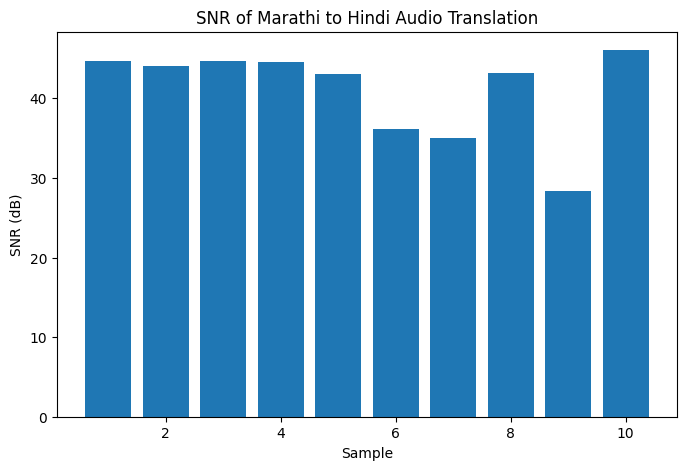

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Sample"], df["SNR (dB)"])

plt.xlabel("Sample")
plt.ylabel("SNR (dB)")
plt.title("SNR of Marathi to Hindi Audio Translation")

plt.show()

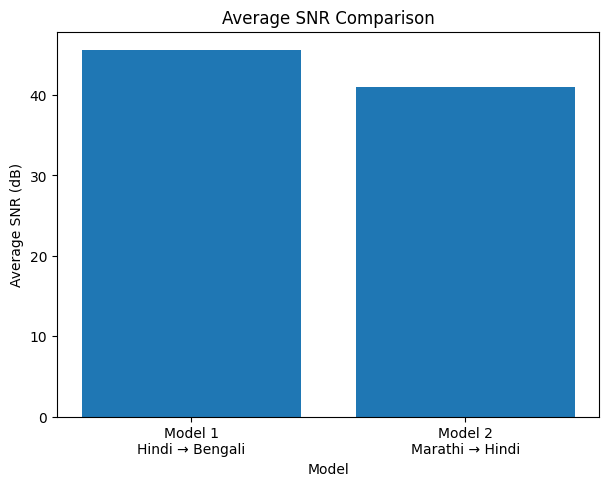

In [45]:
import matplotlib.pyplot as plt

models = ["Model 1\nHindi → Bengali", "Model 2\nMarathi → Hindi"]
snr_values = [45.63, 41.00]

plt.figure(figsize=(7,5))

plt.bar(models, snr_values)

plt.xlabel("Model")
plt.ylabel("Average SNR (dB)")
plt.title("Average SNR Comparison")

plt.show()

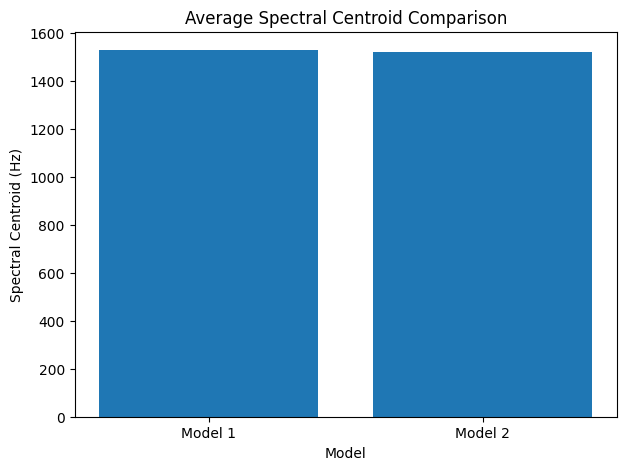

In [46]:
import matplotlib.pyplot as plt

models = ["Model 1", "Model 2"]
centroid = [1529.21, 1523.06]

plt.figure(figsize=(7,5))
plt.bar(models, centroid)

plt.xlabel("Model")
plt.ylabel("Spectral Centroid (Hz)")
plt.title("Average Spectral Centroid Comparison")

plt.show()

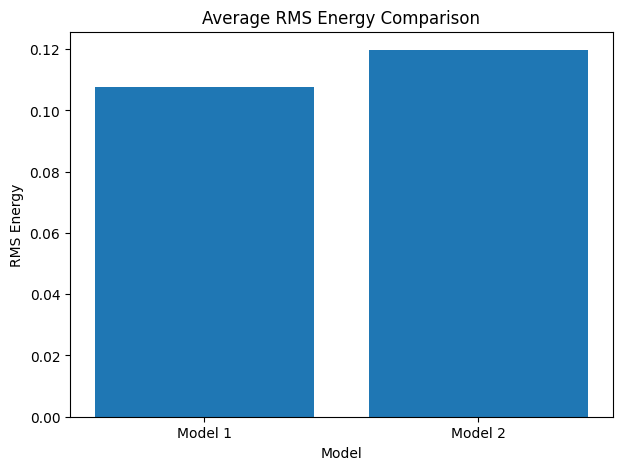

In [47]:
import matplotlib.pyplot as plt

models = ["Model 1", "Model 2"]
rms = [0.1078, 0.1197]

plt.figure(figsize=(7,5))
plt.bar(models, rms)

plt.xlabel("Model")
plt.ylabel("RMS Energy")
plt.title("Average RMS Energy Comparison")

plt.show()